# For-Sale Housing Market Analysis

This notebook evaluates for-sale residential pricing, trends, and competitive positioning in the Clarkston trade area.

It also includes an absorption forecasting workflow to estimate forward sales pace under multiple modeling assumptions.

**Workflow:** clean sales extracts, engineer trend features, fit forecast models, compare scenarios, and summarize implications for market positioning.


In [47]:
# Uncomment if needed
# %pip install -q prophet


In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet


In [49]:
# Create a dataframe for the COVID 'Event' (Holiday Effect for Prophet)
covid_event = pd.DataFrame({
    'holiday': ['covid_anomaly'],
    'ds': pd.to_datetime(['2020-03-01']),
    'lower_window': [0],
    'upper_window': [27]  # Covers 27 months of volatility
})

# Prepare Prophet dataframe (should match the format required for Prophet)
# Use the data already cleaned and prepared in previous cells: 'base_df'
# Just for clarity, reusing base_df which is a DataFrame with columns ['ds', 'y']

# Add the 'holidays' parameter to your model that includes the COVID event window
model = Prophet(holidays=covid_event, yearly_seasonality=True, interval_width=0.95)
model.fit(base_df)

14:10:12 - cmdstanpy - INFO - Chain [1] start processing
14:10:12 - cmdstanpy - INFO - Chain [1] done processing


Regions included in this PMA analysis:
['Avondale Estates, GA' 'Clarkston, GA' 'Decatur, GA' 'North Decatur, GA'
 'North Druid Hills, GA' 'Scottdale, GA' 'Stone Mountain, GA' 'Tucker, GA']



14:10:13 - cmdstanpy - INFO - Chain [1] start processing
14:10:13 - cmdstanpy - INFO - Chain [1] done processing


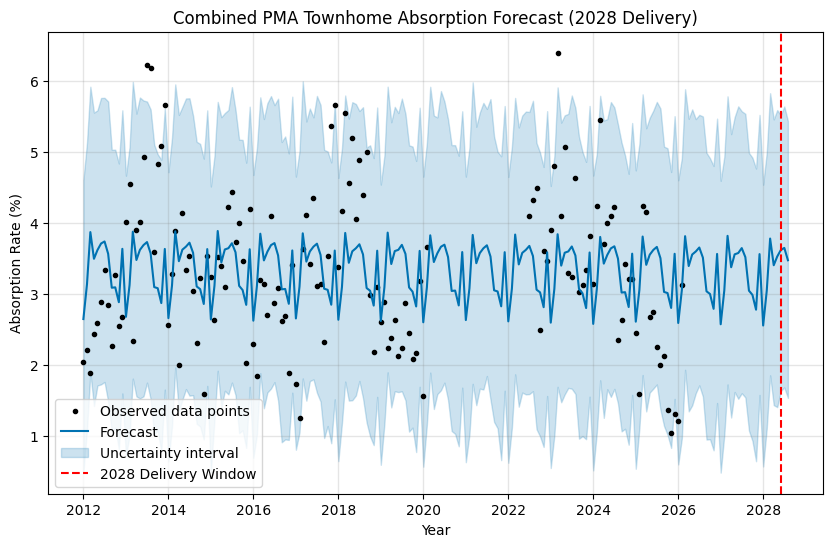

--- 2028 PMA Average Forecast ---
Likely Case: 3.38%
Conservative Floor: 1.41%


In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet

# 1. Load Data
file_path = '../data/Residential_for_Sale/pma_townhome_sales_data.csv'
df = pd.read_csv(file_path, encoding='utf-16', sep='\t')
df.columns = df.columns.str.strip()

# Print regions to confirm we are using all of them
print(f"Regions included in this PMA analysis:\n{df['Region'].unique()}\n")

# 2. Clean the numeric data and dates
df['Homes Sold'] = pd.to_numeric(df['Homes Sold'].astype(str).str.replace(r'[^0-9]', '', regex=True), errors='coerce')
df['Inventory'] = pd.to_numeric(df['Inventory'].astype(str).str.replace(r'[^0-9]', '', regex=True), errors='coerce')
df['Month of Period End'] = pd.to_datetime(df['Month of Period End'], format='%B %Y')

# 3. AGGREGATE DATA FOR ENTIRE PMA
# We sum the inventory and sales for all cities in a given month to get the "Macro" view
pma_df = df.groupby('Month of Period End')[['Homes Sold', 'Inventory']].sum().reset_index()

# 4. Calculate Combined Absorption
pma_df['absorption_rate'] = (pma_df['Homes Sold'] / pma_df['Inventory']) * 100

# Drop any months where inventory was 0 (avoids infinity errors)
pma_df = pma_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['absorption_rate'])

# 5. Prepare for Prophet
base_df = pma_df[['Month of Period End', 'absorption_rate']].rename(columns={'Month of Period End': 'ds', 'absorption_rate': 'y'})

# --- MODEL: PMA FORECAST WITH EXCLUSION ---
df_excl = base_df.copy()

# Mask the COVID anomaly window (March 2020 to June 2022)
df_excl.loc[(df_excl['ds'] >= '2020-03-01') & (df_excl['ds'] <= '2022-06-01'), 'y'] = None

# Initialize and fit
model_excl = Prophet(yearly_seasonality=True, interval_width=0.95)
model_excl.fit(df_excl)

# Predict out to end of 2028 (30 months from mid-2026)
future_excl = model_excl.make_future_dataframe(periods=30, freq='MS')
forecast_excl = model_excl.predict(future_excl)

# Cap lower bounds at zero
forecast_excl['yhat_lower'] = forecast_excl['yhat_lower'].clip(lower=0)
forecast_excl['yhat'] = forecast_excl['yhat'].clip(lower=0)

# Plotting
plt.figure(figsize=(10, 6))
fig_excl = model_excl.plot(forecast_excl, ax=plt.gca())
plt.title("Combined PMA Townhome Absorption Forecast (2028 Delivery)")
plt.axvline(pd.to_datetime('2028-06-01'), color='red', linestyle='--', label='2028 Delivery Window')
plt.ylabel("Absorption Rate (%)")
plt.xlabel("Year")
plt.legend()
plt.show()

# 2028 forecast summary
forecast_2028 = forecast_excl[(forecast_excl['ds'] >= '2028-01-01') & (forecast_excl['ds'] <= '2028-12-31')]
print(f"--- 2028 PMA Average Forecast ---")
print(f"Likely Case: {forecast_2028['yhat'].mean():.2f}%")
print(f"Conservative Floor: {forecast_2028['yhat_lower'].mean():.2f}%")

14:10:14 - cmdstanpy - INFO - Chain [1] start processing
14:10:14 - cmdstanpy - INFO - Chain [1] done processing


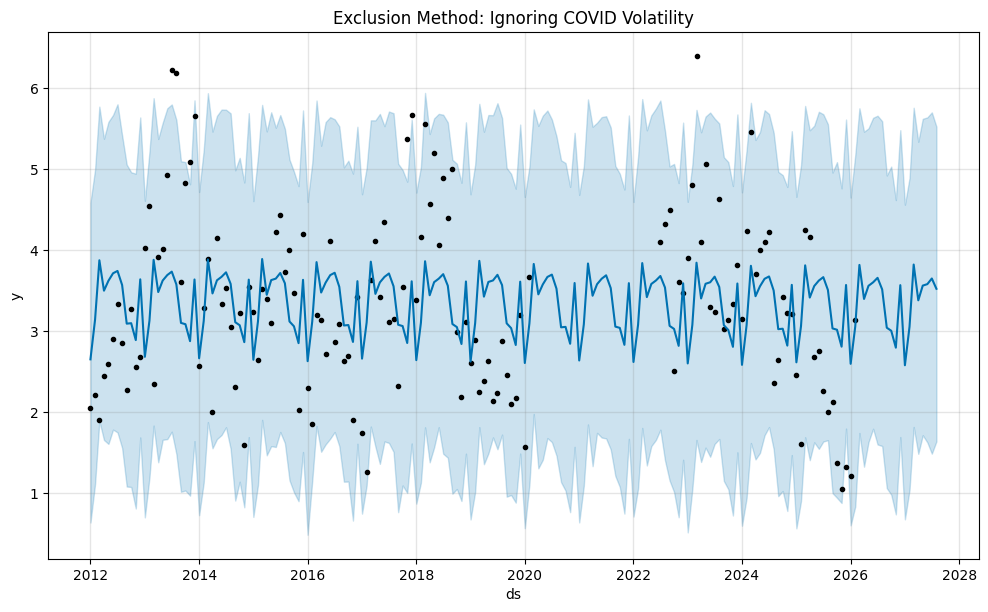

In [51]:
# --- MODEL 1: EXCLUSION ---
df_excl = base_df.copy()
# Masking the COVID window (March 2020 to June 2022)
df_excl.loc[(df_excl['ds'] >= '2020-03-01') & (df_excl['ds'] <= '2022-06-01'), 'y'] = None

model_excl = Prophet(yearly_seasonality=True, interval_width=0.95)
model_excl.fit(df_excl)

future_excl = model_excl.make_future_dataframe(periods=18, freq='MS')
forecast_excl = model_excl.predict(future_excl)

# Plotting
fig_excl = model_excl.plot(forecast_excl)
plt.title("Exclusion Method: Ignoring COVID Volatility")
plt.show()

14:10:15 - cmdstanpy - INFO - Chain [1] start processing
14:10:15 - cmdstanpy - INFO - Chain [1] done processing


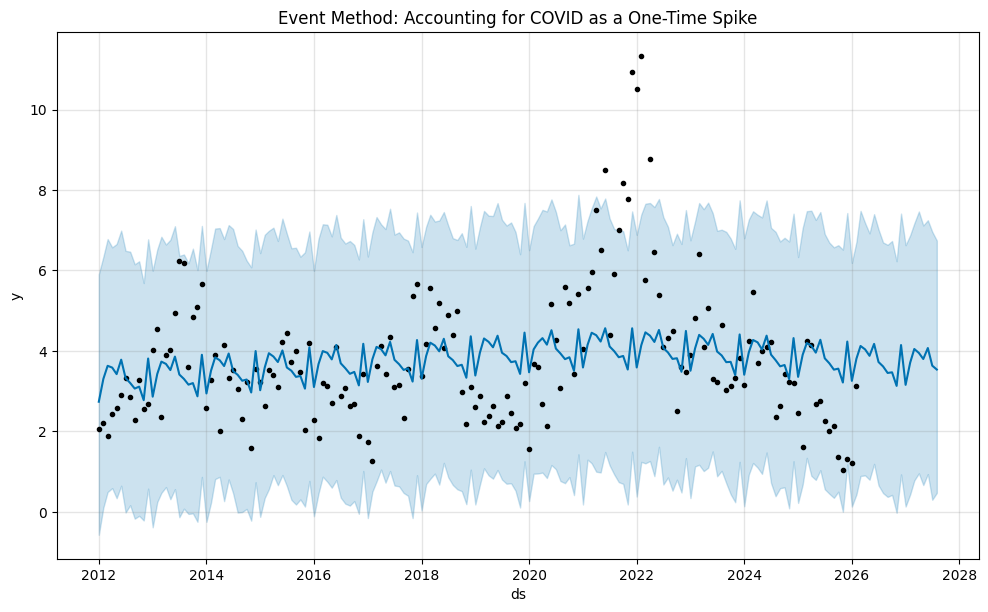

In [52]:
# --- MODEL 2: EVENT/HOLIDAY ---
# Define the COVID period as a 'holiday'
covid_event = pd.DataFrame({
  'holiday': 'covid_anomaly',
  'ds': pd.to_datetime(['2020-03-01']), 
  'lower_window': 0,
  'upper_window': 27, # Covers the ~2 year peak
})

model_event = Prophet(holidays=covid_event, yearly_seasonality=True, interval_width=0.95)
model_event.fit(base_df) # We use the raw base_df here (no None values)

future_event = model_event.make_future_dataframe(periods=18, freq='MS')
forecast_event = model_event.predict(future_event)

# Plotting
fig_event = model_event.plot(forecast_event)
plt.title("Event Method: Accounting for COVID as a One-Time Spike")
plt.show()

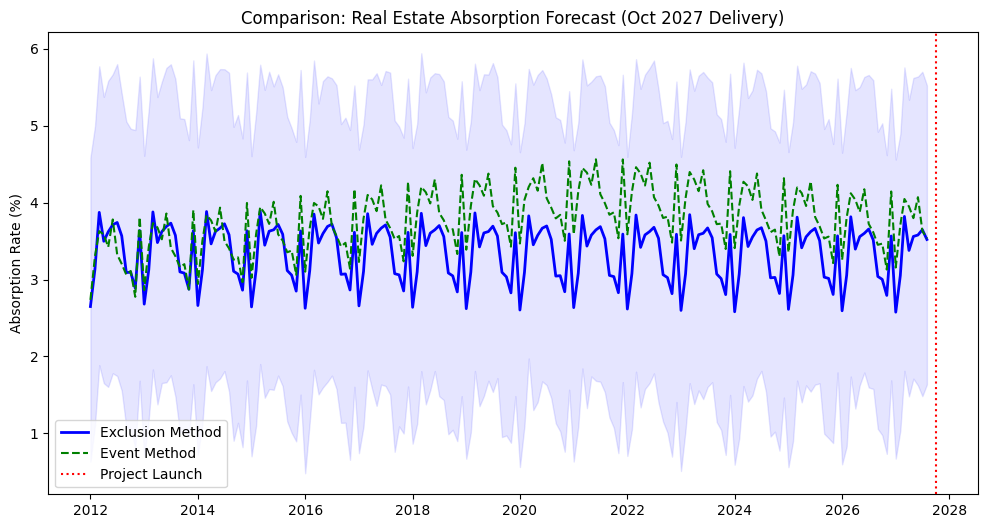

In [53]:
# Compare the 'yhat' (predictions) for both models
plt.figure(figsize=(12, 6))
plt.plot(forecast_excl['ds'], forecast_excl['yhat'], label='Exclusion Method', color='blue', linewidth=2)
plt.plot(forecast_event['ds'], forecast_event['yhat'], label='Event Method', color='green', linestyle='--')

plt.axvline(pd.to_datetime('2027-10-01'), color='red', linestyle=':', label='Project Launch')
plt.fill_between(forecast_excl['ds'], forecast_excl['yhat_lower'], forecast_excl['yhat_upper'], color='blue', alpha=0.1)

plt.title("Comparison: Real Estate Absorption Forecast (Oct 2027 Delivery)")
plt.legend()
plt.ylabel("Absorption Rate (%)")
plt.show()

14:10:17 - cmdstanpy - INFO - Chain [1] start processing
14:10:17 - cmdstanpy - INFO - Chain [1] done processing


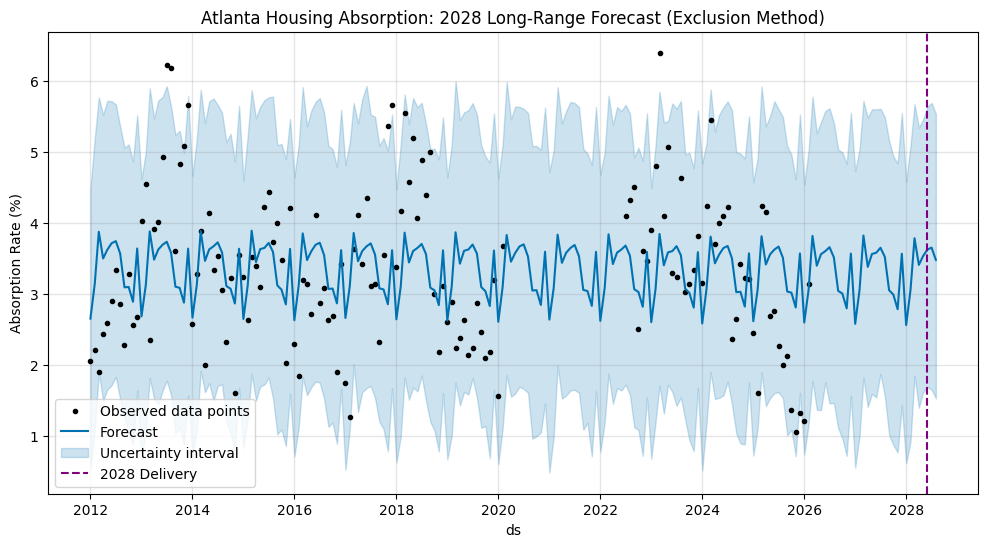

--- Forecasted Market Conditions for 2028 ---
            ds      yhat  yhat_lower  yhat_upper
192 2028-01-01  2.558574    0.608285    4.579215
193 2028-02-01  3.049117    0.910734    5.087285
194 2028-03-01  3.783095    1.843953    5.676950
195 2028-04-01  3.407269    1.391180    5.342551
196 2028-05-01  3.529842    1.609167    5.454815
197 2028-06-01  3.622291    1.683809    5.636951
198 2028-07-01  3.651421    1.648664    5.691430
199 2028-08-01  3.477553    1.523228    5.539978


In [54]:
# 2028 delivery forecast

# 1. Data preparation using the exclusion method
df_2028 = base_df.copy()
# Mask the COVID window
df_2028.loc[(df_2028['ds'] >= '2020-03-01') & (df_2028['ds'] <= '2022-06-01'), 'y'] = None

# 2. Initialize Model
model_2028 = Prophet(yearly_seasonality=True, interval_width=0.95)
model_2028.fit(df_2028)

# 3. Extend forecast to 30 months (through end of 2028)
future_2028 = model_2028.make_future_dataframe(periods=30, freq='MS')
forecast_2028 = model_2028.predict(future_2028)

# 4. Clean up negative values for professional reporting
forecast_2028['yhat_lower'] = forecast_2028['yhat_lower'].clip(lower=0)
forecast_2028['yhat'] = forecast_2028['yhat'].clip(lower=0)

# 5. Visualize 2028 horizon
plt.figure(figsize=(12, 6))
model_2028.plot(forecast_2028, ax=plt.gca())

# Add the 2028 delivery line (assuming June 2028)
plt.axvline(pd.to_datetime('2028-06-01'), color='purple', linestyle='--', label='2028 Delivery')
plt.title("Atlanta Housing Absorption: 2028 Long-Range Forecast (Exclusion Method)")
plt.ylabel("Absorption Rate (%)")
plt.legend()
plt.show()

# 6. 2028 monthly forecast output
print("--- Forecasted Market Conditions for 2028 ---")
print(forecast_2028[(forecast_2028['ds'] >= '2028-01-01') & (forecast_2028['ds'] <= '2028-12-31')][['ds', 'yhat', 'yhat_lower', 'yhat_upper']])

In [55]:
# --- CALCULATE 2028 AVERAGE ABSORPTION ---

# 1. Filter the forecast dataframe for the year 2028
forecast_2028_only = forecast_2028[
    (forecast_2028['ds'] >= '2028-01-01') & 
    (forecast_2028['ds'] <= '2028-12-31')
]

# 2. Calculate the averages
avg_absorption_2028 = forecast_2028_only['yhat'].mean()
min_absorption_2028 = forecast_2028_only['yhat_lower'].mean()
max_absorption_2028 = forecast_2028_only['yhat_upper'].mean()

# 3. Print annual summary metrics
print(f"--- 2028 Yearly Absorption Summary ---")
print(f"Likely Case (Average): {avg_absorption_2028:.2f}%")
print(f"Conservative Case (Floor): {min_absorption_2028:.2f}%")
print(f"Optimistic Case (Ceiling): {max_absorption_2028:.2f}%")

# 4. Calculate the Estimated Sell-Out Period based on the average
sell_out_months_2028 = 1 / (avg_absorption_2028 / 100)
print(f"\nEstimated Project Sell-Out: {sell_out_months_2028:.1f} months")

--- 2028 Yearly Absorption Summary ---
Likely Case (Average): 3.38%
Conservative Case (Floor): 1.40%
Optimistic Case (Ceiling): 5.38%

Estimated Project Sell-Out: 29.5 months


In [56]:
# ==========================================
# SECTION 1: Imports and helper functions
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
import warnings

# Suppress minor Prophet warnings for cleaner output
warnings.filterwarnings('ignore')

def process_redfin_data(file_path):
    """Loads, cleans, and aggregates Redfin data for the entire PMA."""
    # Load data (handling the Excel utf-16 BOM signature)
    df = pd.read_csv(file_path, encoding='utf-16', sep='\t')
    df.columns = df.columns.str.strip()
    
    # Clean numeric columns
    df['Homes Sold'] = pd.to_numeric(df['Homes Sold'].astype(str).str.replace(r'[^0-9]', '', regex=True), errors='coerce')
    df['Inventory'] = pd.to_numeric(df['Inventory'].astype(str).str.replace(r'[^0-9]', '', regex=True), errors='coerce')
    df['Month of Period End'] = pd.to_datetime(df['Month of Period End'], format='%B %Y')
    
    # Aggregate data for the entire PMA (summing all cities)
    pma_df = df.groupby('Month of Period End')[['Homes Sold', 'Inventory']].sum().reset_index()
    
    # Calculate Absorption Rate
    pma_df['absorption_rate'] = (pma_df['Homes Sold'] / pma_df['Inventory']) * 100
    pma_df = pma_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['absorption_rate'])
    
    # Rename for Prophet
    base_df = pma_df[['Month of Period End', 'absorption_rate']].rename(columns={'Month of Period End': 'ds', 'absorption_rate': 'y'})
    return base_df

def forecast_absorption(base_df, title_label):
    """Runs the Prophet model with the COVID Exclusion method and outputs 2028 data."""
    df_excl = base_df.copy()
    
    # Exclude COVID Anomaly Window (March 2020 - June 2022)
    df_excl.loc[(df_excl['ds'] >= '2020-03-01') & (df_excl['ds'] <= '2022-06-01'), 'y'] = None
    
    # Initialize and Fit Model (using Newton to prevent the L-BFGS crash)
    model = Prophet(yearly_seasonality=True, interval_width=0.95)
    model.fit(df_excl, algorithm='Newton')
    
    # Forecast out 30 periods to end of 2028
    future = model.make_future_dataframe(periods=30, freq='MS')
    forecast = model.predict(future)
    
    # Cap lower bounds at zero
    forecast['yhat_lower'] = forecast['yhat_lower'].clip(lower=0)
    forecast['yhat'] = forecast['yhat'].clip(lower=0)
    
    # Plotting
    plt.figure(figsize=(10, 5))
    model.plot(forecast, ax=plt.gca())
    plt.title(f"PMA Absorption Forecast (2028 Delivery): {title_label}", fontsize=14)
    plt.axvline(pd.to_datetime('2028-06-01'), color='red', linestyle='--', label='2028 Delivery')
    plt.ylabel("Absorption Rate (%)")
    plt.xlabel("Year")
    plt.legend()
    plt.show()
    
    # 2028 Pro-Forma Summary
    forecast_2028 = forecast[(forecast['ds'] >= '2028-01-01') & (forecast['ds'] <= '2028-12-31')]
    avg_abs = forecast_2028['yhat'].mean()
    min_abs = forecast_2028['yhat_lower'].mean()
    max_abs = forecast_2028['yhat_upper'].mean()
    
    print(f"=== 2028 PMA Summary: {title_label} ===")
    print(f"Likely Absorption (Average):   {avg_abs:.2f}%")
    print(f"Conservative Floor (Worst):    {min_abs:.2f}%")
    print(f"Optimistic Ceiling (Best):     {max_abs:.2f}%")
    print(f"Estimated Sell-Out Time:       {(1 / (avg_abs / 100)):.1f} months\n")
    
    return forecast

Processing All Residential Data...


14:10:19 - cmdstanpy - INFO - Chain [1] start processing
14:10:20 - cmdstanpy - INFO - Chain [1] done processing


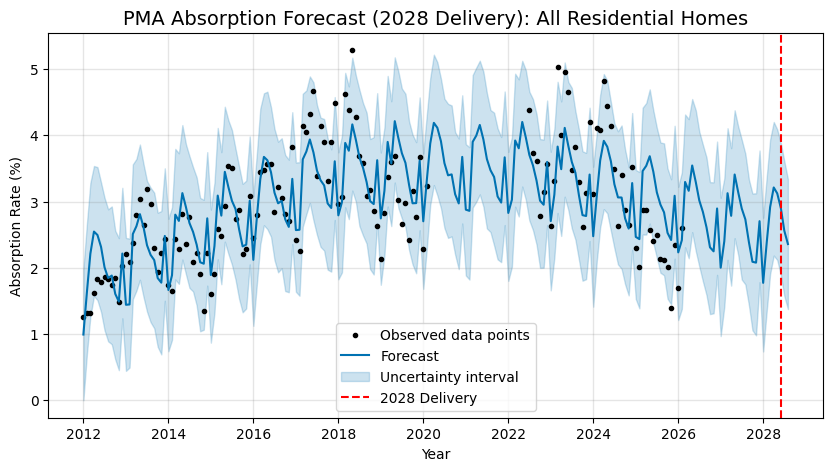

=== 2028 PMA Summary: All Residential Homes ===
Likely Absorption (Average):   2.65%
Conservative Floor (Worst):    1.64%
Optimistic Ceiling (Best):     3.65%
Estimated Sell-Out Time:       37.7 months



In [57]:
# ==========================================
# SECTION 2: All-residential market analysis
# ==========================================

# Define file path
path_all_resi = '../data/Residential_for_Sale/pma_all_resi_sales_data.csv'

# Process the data
print("Processing All Residential Data...")
df_all_resi = process_redfin_data(path_all_resi)

# Run the forecast
forecast_all_resi = forecast_absorption(df_all_resi, "All Residential Homes")

Processing Townhome Data...


14:10:21 - cmdstanpy - INFO - Chain [1] start processing


14:10:23 - cmdstanpy - INFO - Chain [1] done processing


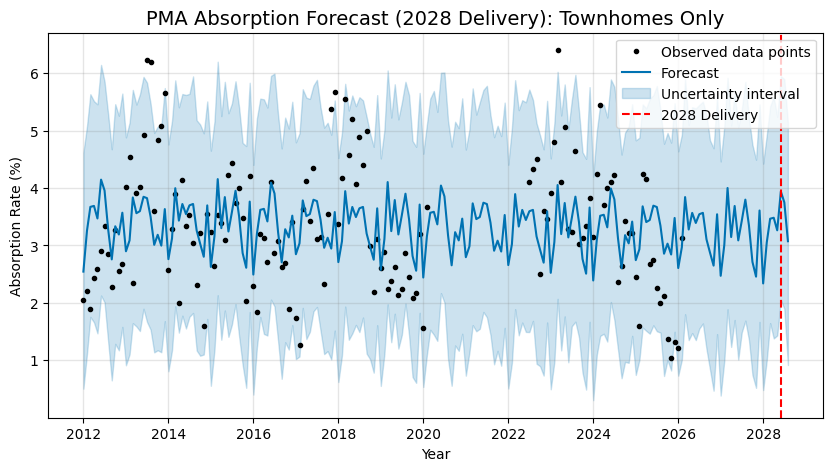

=== 2028 PMA Summary: Townhomes Only ===
Likely Absorption (Average):   3.30%
Conservative Floor (Worst):    1.35%
Optimistic Ceiling (Best):     5.32%
Estimated Sell-Out Time:       30.3 months



In [58]:
# ==========================================
# SECTION 3: Townhome market analysis
# ==========================================

# Define file path
path_townhomes = '../data/Residential_for_Sale/pma_townhome_sales_data.csv'

# Process the data
print("Processing Townhome Data...")
df_townhomes = process_redfin_data(path_townhomes)

# Run the forecast
forecast_townhomes = forecast_absorption(df_townhomes, "Townhomes Only")

In [59]:
# ==========================================
# SECTION 1: Imports and helper functions
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
import warnings

# Suppress minor warnings for a clean output
warnings.filterwarnings('ignore')

def process_redfin_data(file_path):
    """Loads, cleans, and aggregates Redfin data with automatic encoding detection."""
    # Try UTF-16 first, fallback to UTF-8 if it fails (handles Redfin's mixed exports)
    try:
        df = pd.read_csv(file_path, encoding='utf-16', sep='\t')
    except (UnicodeError, UnicodeDecodeError):
        df = pd.read_csv(file_path, encoding='utf-8', sep='\t')
        
    df.columns = df.columns.str.strip()
    
    # Clean numeric columns
    df['Homes Sold'] = pd.to_numeric(df['Homes Sold'].astype(str).str.replace(r'[^0-9]', '', regex=True), errors='coerce')
    df['Inventory'] = pd.to_numeric(df['Inventory'].astype(str).str.replace(r'[^0-9]', '', regex=True), errors='coerce')
    df['Month of Period End'] = pd.to_datetime(df['Month of Period End'], format='%B %Y')
    
    # Aggregate data (Works for both multi-city PMAs and single-region Atlanta data)
    aggregated_df = df.groupby('Month of Period End')[['Homes Sold', 'Inventory']].sum().reset_index()
    
    # Calculate Absorption Rate
    aggregated_df['absorption_rate'] = (aggregated_df['Homes Sold'] / aggregated_df['Inventory']) * 100
    aggregated_df = aggregated_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['absorption_rate'])
    
    # Rename for Prophet
    base_df = aggregated_df[['Month of Period End', 'absorption_rate']].rename(columns={'Month of Period End': 'ds', 'absorption_rate': 'y'})
    return base_df

def forecast_absorption(base_df, title_label):
    """Runs Prophet (excluding COVID) and outputs the 2028 forecast dataframe."""
    df_excl = base_df.copy()
    
    # Exclude COVID Anomaly Window (March 2020 - June 2022)
    df_excl.loc[(df_excl['ds'] >= '2020-03-01') & (df_excl['ds'] <= '2022-06-01'), 'y'] = None
    
    # Initialize and Fit Model (using Newton to prevent the L-BFGS crash)
    model = Prophet(yearly_seasonality=True, interval_width=0.95)
    model.fit(df_excl, algorithm='Newton')
    
    # Forecast out 30 periods to end of 2028
    future = model.make_future_dataframe(periods=30, freq='MS')
    forecast = model.predict(future)
    
    # Cap lower bounds at zero
    forecast['yhat_lower'] = forecast['yhat_lower'].clip(lower=0)
    forecast['yhat'] = forecast['yhat'].clip(lower=0)
    
    # --- VISUALIZATION 1: Main Forecast ---
    plt.figure(figsize=(10, 5))
    model.plot(forecast, ax=plt.gca())
    plt.title(f"Absorption Forecast (2028 Delivery): {title_label}", fontsize=14)
    plt.axvline(pd.to_datetime('2028-06-01'), color='red', linestyle='--', label='2028 Delivery')
    plt.ylabel("Absorption Rate (%)")
    plt.xlabel("Year")
    plt.legend()
    plt.show()
    
    # --- Visualization 2: model components (trend and seasonality) ---
    fig2 = model.plot_components(forecast)
    plt.show()
    
    # 2028 Pro-Forma Summary
    forecast_2028 = forecast[(forecast['ds'] >= '2028-01-01') & (forecast['ds'] <= '2028-12-31')]
    avg_abs = forecast_2028['yhat'].mean()
    
    print(f"✅ Processed: {title_label} | Est. 2028 Absorption: {avg_abs:.2f}% | Sell-Out: {(1 / (avg_abs / 100)):.1f} mos\n")
    return forecast

14:10:26 - cmdstanpy - INFO - Chain [1] start processing


14:10:27 - cmdstanpy - INFO - Chain [1] done processing


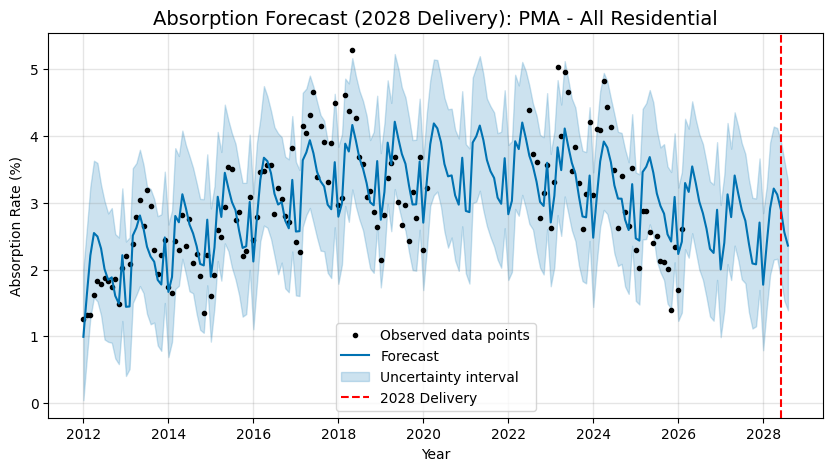

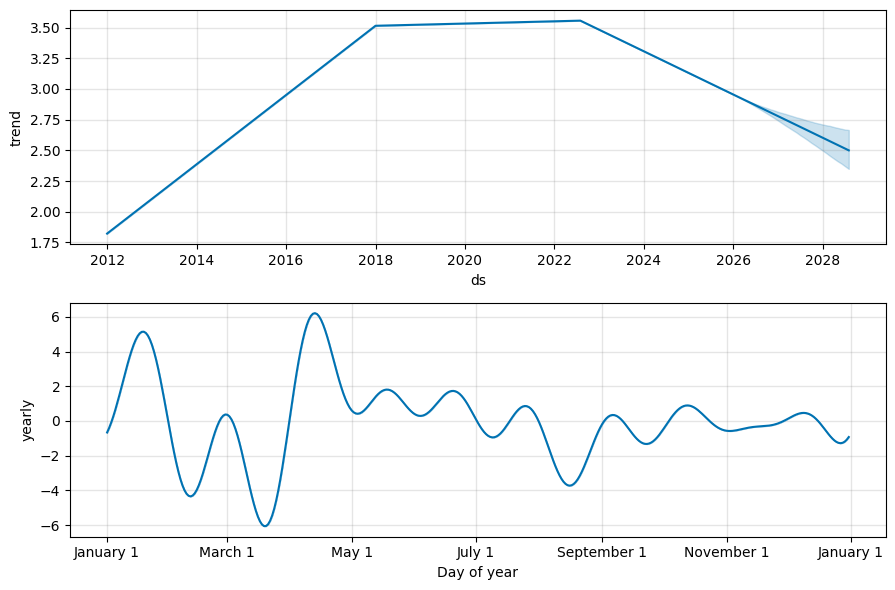

14:10:32 - cmdstanpy - INFO - Chain [1] start processing


✅ Processed: PMA - All Residential | Est. 2028 Absorption: 2.65% | Sell-Out: 37.7 mos



14:10:34 - cmdstanpy - INFO - Chain [1] done processing


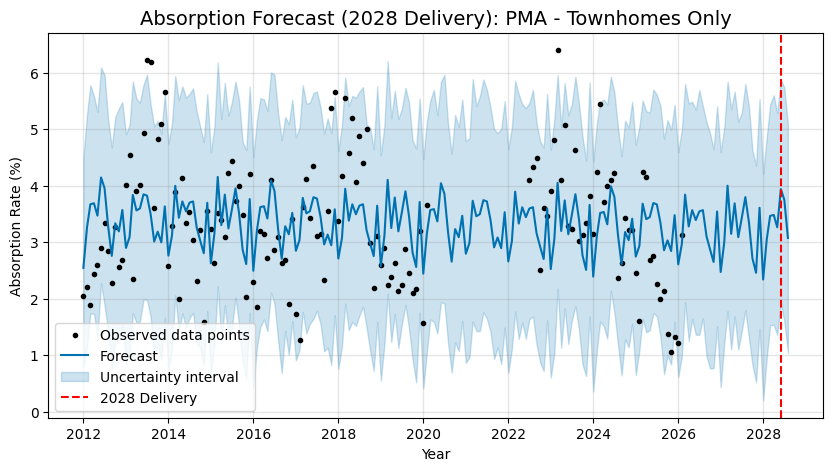

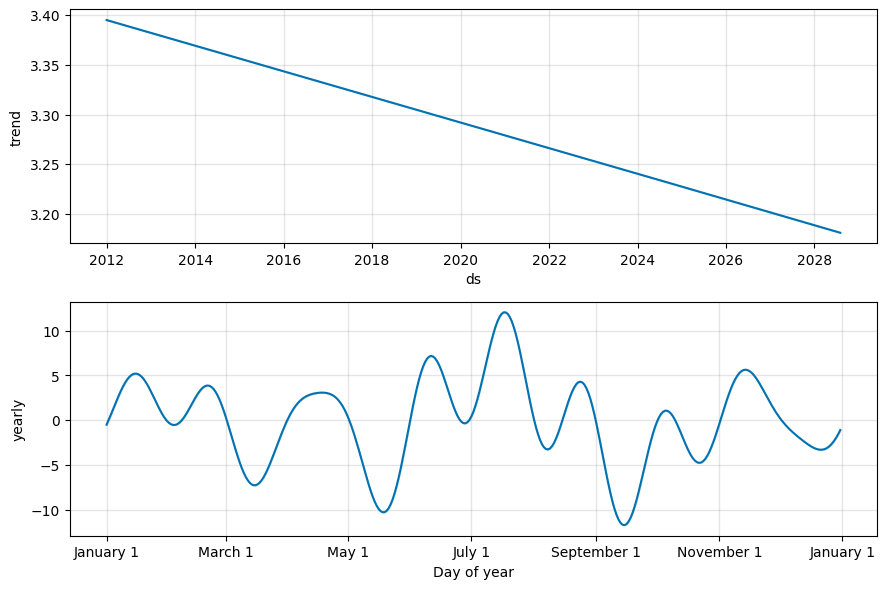

✅ Processed: PMA - Townhomes Only | Est. 2028 Absorption: 3.30% | Sell-Out: 30.3 mos



In [60]:
# ==========================================
# SECTION 2: Project PMA analysis
# ==========================================

# 1. PMA All Residential
path_pma_all = '../data/Residential_for_Sale/pma_all_resi_sales_data.csv'
df_pma_all = process_redfin_data(path_pma_all)
forecast_pma_all = forecast_absorption(df_pma_all, "PMA - All Residential")

# 2. PMA Townhomes Only
path_pma_towns = '../data/Residential_for_Sale/pma_townhome_sales_data.csv'
df_pma_towns = process_redfin_data(path_pma_towns)
forecast_pma_towns = forecast_absorption(df_pma_towns, "PMA - Townhomes Only")

14:10:36 - cmdstanpy - INFO - Chain [1] start processing
14:10:39 - cmdstanpy - INFO - Chain [1] done processing


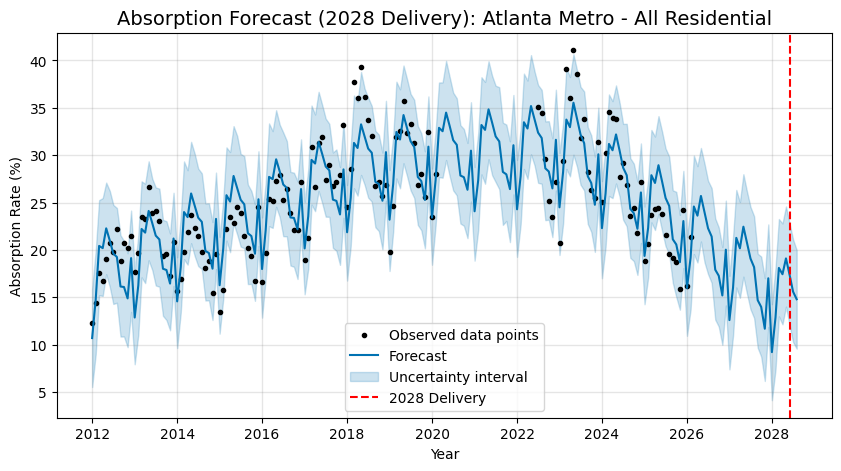

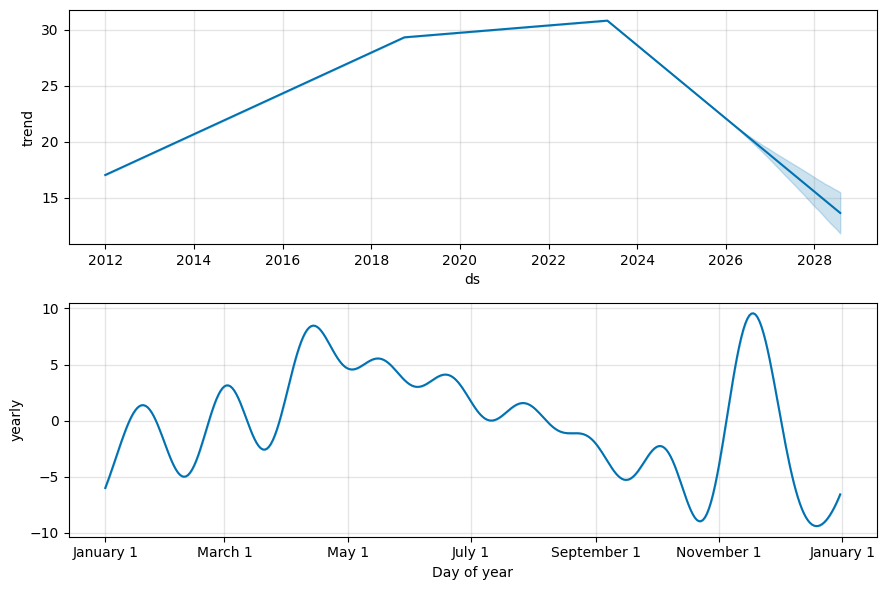

14:10:40 - cmdstanpy - INFO - Chain [1] start processing


✅ Processed: Atlanta Metro - All Residential | Est. 2028 Absorption: 15.57% | Sell-Out: 6.4 mos



14:10:42 - cmdstanpy - INFO - Chain [1] done processing


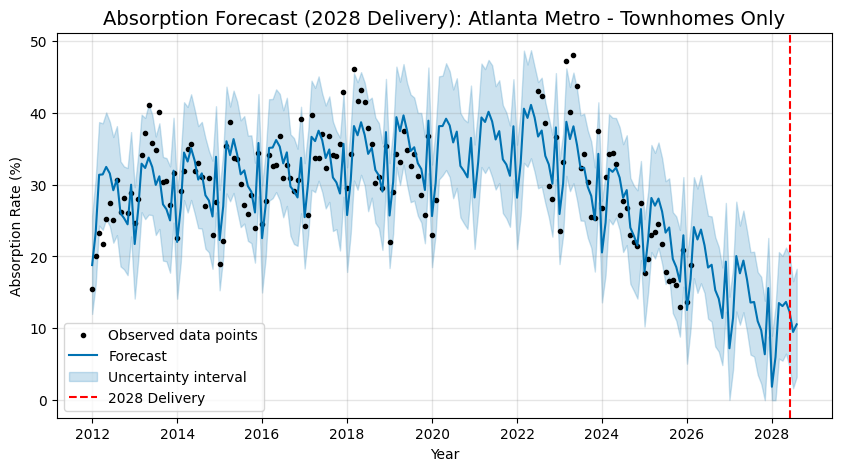

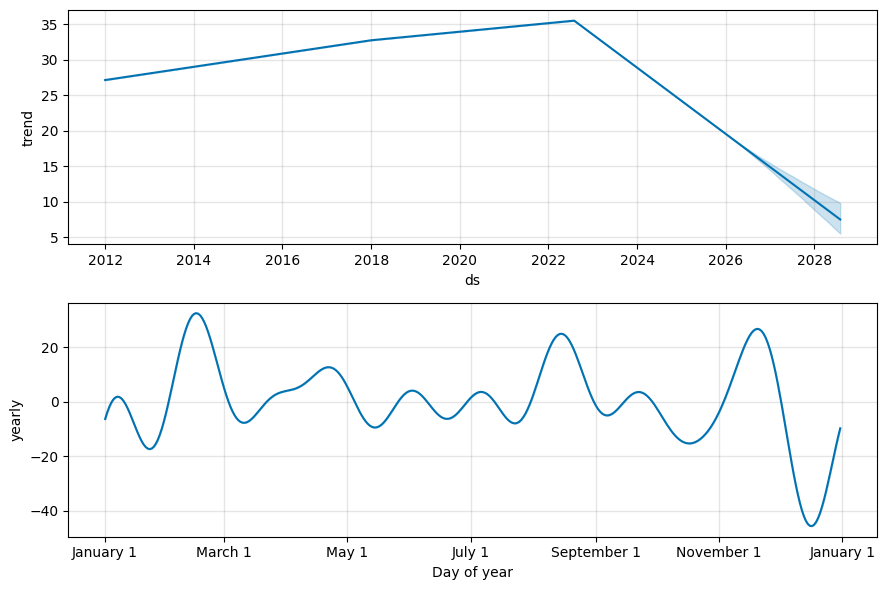

✅ Processed: Atlanta Metro - Townhomes Only | Est. 2028 Absorption: 10.06% | Sell-Out: 9.9 mos



In [61]:
# ==========================================
# SECTION 3: Atlanta metro market analysis
# ==========================================

# 3. Atlanta All Residential
path_atl_all = '../data/Residential_for_Sale/atl_metro_all_resi_sales.csv'
df_atl_all = process_redfin_data(path_atl_all)
forecast_atl_all = forecast_absorption(df_atl_all, "Atlanta Metro - All Residential")

# 4. Atlanta Townhomes Only
path_atl_towns = '../data/Residential_for_Sale/atl_metro_townhome_sales.csv'
df_atl_towns = process_redfin_data(path_atl_towns)
forecast_atl_towns = forecast_absorption(df_atl_towns, "Atlanta Metro - Townhomes Only")

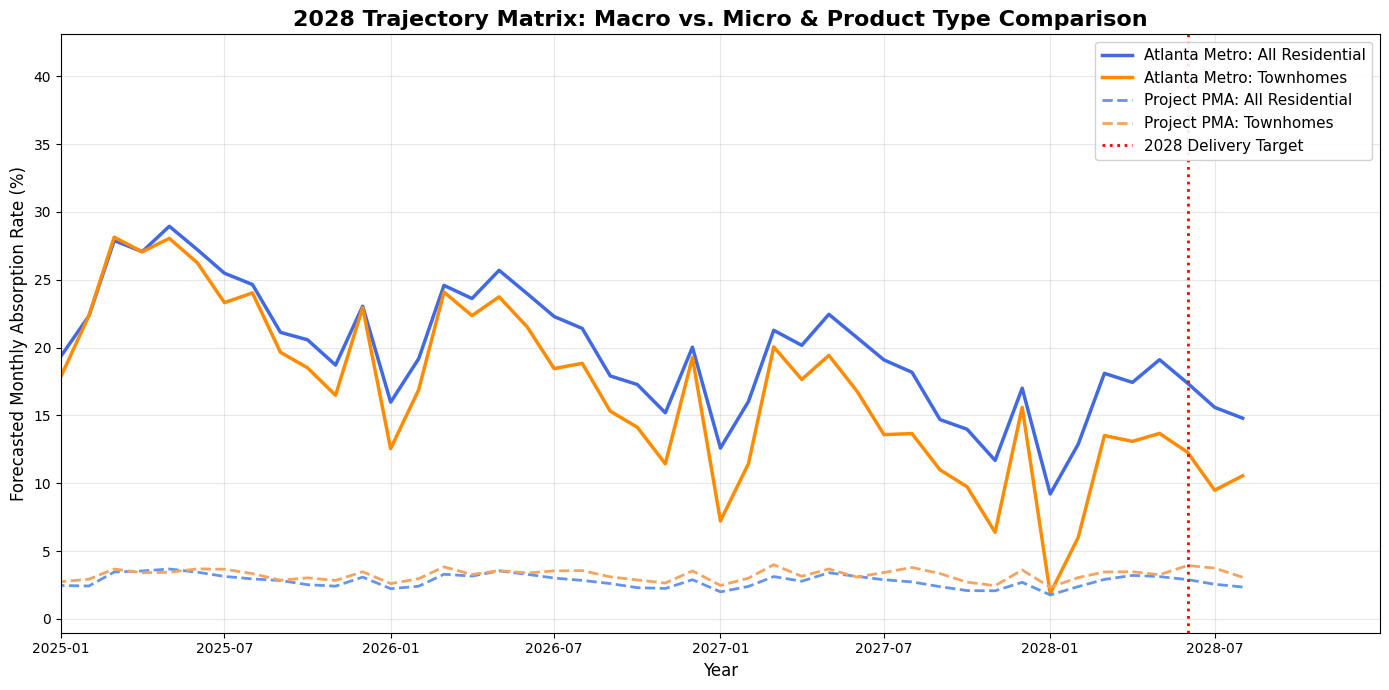

In [62]:
# ==========================================
# SECTION 4: Macro vs. project PMA comparison
# ==========================================

plt.figure(figsize=(14, 7))

# 1. Macro: Atlanta All Residential (Thick Blue Line)
plt.plot(forecast_atl_all['ds'], forecast_atl_all['yhat'], 
         label='Atlanta Metro: All Residential', color='royalblue', linewidth=2.5)

# 2. Macro: Atlanta Townhomes (Thick Orange Line)
plt.plot(forecast_atl_towns['ds'], forecast_atl_towns['yhat'], 
         label='Atlanta Metro: Townhomes', color='darkorange', linewidth=2.5)

# 3. Micro: PMA All Residential (Dashed Blue Line)
plt.plot(forecast_pma_all['ds'], forecast_pma_all['yhat'], 
         label='Project PMA: All Residential', color='cornflowerblue', linestyle='--', linewidth=2)

# 4. Micro: PMA Townhomes (Dashed Orange Line)
plt.plot(forecast_pma_towns['ds'], forecast_pma_towns['yhat'], 
         label='Project PMA: Townhomes', color='sandybrown', linestyle='--', linewidth=2)

# Focus the graph on the future (2025 to end of 2028)
plt.xlim(pd.to_datetime('2025-01-01'), pd.to_datetime('2028-12-31'))

# Formatting & 2028 delivery marker
plt.axvline(pd.to_datetime('2028-06-01'), color='red', linestyle=':', linewidth=2, label='2028 Delivery Target')
plt.title("2028 Trajectory Matrix: Macro vs. Micro & Product Type Comparison", fontsize=16, fontweight='bold')
plt.ylabel("Forecasted Monthly Absorption Rate (%)", fontsize=12)
plt.xlabel("Year", fontsize=12)

# Legend and layout formatting
plt.legend(loc='upper right', fontsize=11, framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [63]:
# ==========================================
# SECTION 5: Executive summary matrix
# ==========================================
from IPython.display import display, HTML

def get_summary_metrics(df, forecast, label):
    """Extracts current and forecasted metrics for the summary table."""
    # Get the most recent actual data point (Current Market)
    current_data = df.dropna(subset=['y']).iloc[-1]
    current_date = current_data['ds'].strftime('%b %Y')
    current_abs = current_data['y']
    
    # Get the 2028 forecast average
    forecast_2028 = forecast[(forecast['ds'] >= '2028-01-01') & (forecast['ds'] <= '2028-12-31')]
    avg_2028 = forecast_2028['yhat'].mean()
    
    # Calculate Sell-Out Time (Months of Supply)
    sell_out = (1 / (avg_2028 / 100)) if avg_2028 > 0 else float('inf')
    
    return {
        "Market / Product Type": label,
        f"Current Rate ({current_date})": f"{current_abs:.2f}%",
        "2028 Forecast Rate": f"{avg_2028:.2f}%",
        "2028 Pro-Forma Sell-Out": f"{sell_out:.1f} months"
    }

# Compile the data from the previous chunks
summary_data = [
    get_summary_metrics(df_atl_all, forecast_atl_all, "Atlanta Metro: All Residential"),
    get_summary_metrics(df_atl_towns, forecast_atl_towns, "Atlanta Metro: Townhomes"),
    get_summary_metrics(df_pma_all, forecast_pma_all, "Project PMA: All Residential"),
    get_summary_metrics(df_pma_towns, forecast_pma_towns, "Project PMA: Townhomes")
]

# Create the Pandas DataFrame
summary_table = pd.DataFrame(summary_data)

# Table formatting
display(HTML("<h3><b style='color:#2c3e50;'>Absorption Summary Matrix (Current vs. 2028)</b></h3>"))
display(summary_table.style.set_properties(**{
    'background-color': '#f8f9fa',
    'border': '1px solid black',
    'padding': '10px',
    'text-align': 'center'
}).set_table_styles([{
    'selector': 'th',
    'props': [('background-color', '#2c3e50'), ('color', 'white'), ('text-align', 'center'), ('font-size', '14px')]
}]))

,Market / Product Type,Current Rate (Feb 2026),2028 Forecast Rate,2028 Pro-Forma Sell-Out
0,Atlanta Metro: All Residential,21.40%,15.57%,6.4 months
1,Atlanta Metro: Townhomes,18.81%,10.06%,9.9 months
2,Project PMA: All Residential,2.60%,2.65%,37.7 months
3,Project PMA: Townhomes,3.13%,3.30%,30.3 months


In [64]:
# ==========================================
# SECTION 5: Executive summary matrix (risk bands)
# ==========================================
from IPython.display import display, HTML
import pandas as pd

def get_summary_metrics(df, forecast, label):
    """Extracts current and forecasted metrics, including risk bands, for the summary table."""
    # Get the most recent actual data point (Current Market)
    current_data = df.dropna(subset=['y']).iloc[-1]
    current_date = current_data['ds'].strftime('%b %Y')
    current_abs = current_data['y']
    
    # Get the 2028 forecast average, min, and max
    forecast_2028 = forecast[(forecast['ds'] >= '2028-01-01') & (forecast['ds'] <= '2028-12-31')]
    avg_2028 = forecast_2028['yhat'].mean()
    min_2028 = forecast_2028['yhat_lower'].mean()
    max_2028 = forecast_2028['yhat_upper'].mean()
    
    # Calculate Sell-Out Time (Months of Supply) based on the likely average
    sell_out = (1 / (avg_2028 / 100)) if avg_2028 > 0 else float('inf')
    
    return {
        "Market / Product Type": label,
        f"Current Rate ({current_date})": f"{current_abs:.2f}%",
        "2028 Min (Floor)": f"{min_2028:.2f}%",
        "2028 Avg (Likely)": f"{avg_2028:.2f}%",
        "2028 Max (Ceiling)": f"{max_2028:.2f}%",
        "2028 Pro-Forma Sell-Out": f"{sell_out:.1f} months"
    }

# Compile the data from the previous chunks
summary_data = [
    get_summary_metrics(df_atl_all, forecast_atl_all, "Atlanta Metro: All Residential"),
    get_summary_metrics(df_atl_towns, forecast_atl_towns, "Atlanta Metro: Townhomes"),
    get_summary_metrics(df_pma_all, forecast_pma_all, "Project PMA: All Residential"),
    get_summary_metrics(df_pma_towns, forecast_pma_towns, "Project PMA: Townhomes")
]

# Create the Pandas DataFrame
summary_table = pd.DataFrame(summary_data)

# Table formatting
display(HTML("<h3><b style='color:#2c3e50;'>Absorption Summary Matrix (Current vs. 2028 with Risk Bands)</b></h3>"))
display(summary_table.style.set_properties(**{
    'background-color': '#f8f9fa',
    'border': '1px solid black',
    'padding': '10px',
    'text-align': 'center'
}).set_table_styles([{
    'selector': 'th',
    'props': [('background-color', '#2c3e50'), ('color', 'white'), ('text-align', 'center'), ('font-size', '14px')]
}]))

,Market / Product Type,Current Rate (Feb 2026),2028 Min (Floor),2028 Avg (Likely),2028 Max (Ceiling),2028 Pro-Forma Sell-Out
0,Atlanta Metro: All Residential,21.40%,10.33%,15.57%,20.87%,6.4 months
1,Atlanta Metro: Townhomes,18.81%,3.41%,10.06%,17.36%,9.9 months
2,Project PMA: All Residential,2.60%,1.65%,2.65%,3.64%,37.7 months
3,Project PMA: Townhomes,3.13%,1.27%,3.30%,5.27%,30.3 months
